# Notebook 2 — Zero-shot evaluation on additional low-resource languages

## Project
IsoColBERT: Token-Level Isotropy Regularization for Multilingual Late-Interaction Retrieval
Minh Tran, Isaac Chang, Ingrid Chien — Harvard University

## What this notebook does
Evaluation-only (no retraining) on the 6 checkpoints produced by Notebook 1. Adds three additional low-resource zero-shot targets: Yoruba (YO), Nepali (NE), Tamil (TA). Merges these into the combined metrics JSON for downstream analysis. The paper reports NE and TA (Yoruba is excluded due to extremely low baseline P@1).

**Status:** Evaluated. Results are embedded in cell outputs. No new training.

## Outputs produced (or designed to produce)
- EN-YO, EN-NE, EN-TA MaxSim P@1, 3-seed mean ± std
- Combined metrics JSON for all 7 languages

## Where this feeds into the paper
- Section 5.1 (Retrieval Accuracy) — EN-NE and EN-TA rows in the main table

## Reproducibility
- **Model**: XLM-RoBERTa-base + 128-dim linear projection (ColBERT-style late interaction)
- **Training data**: OPUS-100 English-Spanish parallel split, streamed from HuggingFace
- **Evaluation**: FLORES+ dev + devtest combined (≈2009 candidates per language)
- **Seeds**: {42, 1337, 2024}
- **Hardware**: Single NVIDIA A100 (Colab Pro). ~1 GPU-hour per training run.
- **Drive layout**: checkpoints save to `/MyDrive/iso_colbert_lam0p5/`, `/MyDrive/iso_colbert_active_token/`, `/MyDrive/iso_colbert_crossattn/`.

---


In [1]:
!pip install -q transformers datasets torch

In [10]:
import os, json, gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import XLMRobertaModel, XLMRobertaTokenizerFast
from datasets import load_dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DIM = 128
MAX_LEN = 64
LAMBDA_ISO = 0.5

SEEDS = [42, 1337, 2024]
METHODS = ['vanilla', 'iso_lam0p5']

# Option A: if you added the shared folder shortcut to My Drive
SAVE_DIR = '/content/drive/MyDrive/iso_colbert_lam0p5'

# Option B: if you manually upload the 6 .pt files into Colab directly, use this instead:
# SAVE_DIR = '/content'

print('DEVICE:', DEVICE)
print('SAVE_DIR:', SAVE_DIR)

DEVICE: cuda
SAVE_DIR: /content/drive/MyDrive/iso_colbert_lam0p5


In [11]:
from google.colab import drive
drive.mount('/content/drive')

assert os.path.exists(SAVE_DIR), f'Folder not found: {SAVE_DIR}'
print('Drive mounted and folder exists.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and folder exists.


In [12]:
tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')

class ColBERTEncoder(nn.Module):
    def __init__(self, dim=DIM):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        self.linear = nn.Linear(768, dim)

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        token_vecs = self.linear(out.last_hidden_state)
        token_vecs = F.normalize(token_vecs, dim=-1)
        return token_vecs, attention_mask.bool()

    def forward(self, input_ids, attention_mask):
        token_vecs, mask = self.encode(input_ids, attention_mask)
        m = mask.unsqueeze(-1).float()
        pooled = (token_vecs * m).sum(1) / m.sum(1).clamp(min=1e-9)
        return F.normalize(pooled, dim=-1)

print('Model class ready. No training.')

Model class ready. No training.


In [13]:
def get_ckpt_path(method, seed):
    return os.path.join(SAVE_DIR, f'{method}_lam{LAMBDA_ISO}_seed{seed}.pt')

print('Checking saved checkpoint files:')

all_ok = True
for seed in SEEDS:
    for method in METHODS:
        p = get_ckpt_path(method, seed)
        ok = os.path.exists(p)
        all_ok = all_ok and ok
        print(f'{method:12s} seed {seed}: {ok} | {p}')

assert all_ok, 'Some checkpoint files are missing. Stop here before eval.'
print('\nAll 6 checkpoints found.')

Checking saved checkpoint files:
vanilla      seed 42: True | /content/drive/MyDrive/iso_colbert_lam0p5/vanilla_lam0.5_seed42.pt
iso_lam0p5   seed 42: True | /content/drive/MyDrive/iso_colbert_lam0p5/iso_lam0p5_lam0.5_seed42.pt
vanilla      seed 1337: True | /content/drive/MyDrive/iso_colbert_lam0p5/vanilla_lam0.5_seed1337.pt
iso_lam0p5   seed 1337: True | /content/drive/MyDrive/iso_colbert_lam0p5/iso_lam0p5_lam0.5_seed1337.pt
vanilla      seed 2024: True | /content/drive/MyDrive/iso_colbert_lam0p5/vanilla_lam0.5_seed2024.pt
iso_lam0p5   seed 2024: True | /content/drive/MyDrive/iso_colbert_lam0p5/iso_lam0p5_lam0.5_seed2024.pt

All 6 checkpoints found.


In [14]:
def load_flores_pairs(lang_code, split='dev'):
    src = load_dataset('openlanguagedata/flores_plus', 'eng_Latn', split=split)
    tgt = load_dataset('openlanguagedata/flores_plus', lang_code, split=split)
    return [(s['text'], t['text']) for s, t in zip(src, tgt)]

def combined(lang_code):
    return load_flores_pairs(lang_code, 'dev') + load_flores_pairs(lang_code, 'devtest')

print('FLORES+ loader ready.')

FLORES+ loader ready.


In [15]:
LOW_RESOURCE_LANGS = {
    'yo': ('yor_Latn', 'EN-YO MaxSim P@1 zero-shot low-resource'),  # Yoruba
    'ne': ('npi_Deva', 'EN-NE MaxSim P@1 zero-shot low-resource'),  # Nepali
    'ta': ('tam_Taml', 'EN-TA MaxSim P@1 zero-shot low-resource'),  # Tamil
}

eval_pairs = {}

for short, (code, label) in LOW_RESOURCE_LANGS.items():
    print(f'Loading {short}: {code}')
    eval_pairs[short] = combined(code)
    print(f'  {short}: {len(eval_pairs[short])} pairs')

print('Loaded all eval datasets.')

Loading yo: yor_Latn


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

  ta: 2009 pairs
Loaded all eval datasets.


In [16]:
@torch.no_grad()
def encode_all_padded(model, texts, max_len=MAX_LEN, batch_size=64):
    model.eval()
    raw_v, raw_m = [], []
    L_max = 0

    for i in range(0, len(texts), batch_size):
        tok = tokenizer(
            texts[i:i+batch_size],
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        tok = {k: v.to(DEVICE) for k, v in tok.items()}

        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        raw_v.append(v)
        raw_m.append(m)
        L_max = max(L_max, v.size(1))

    padded_v, padded_m = [], []

    for v, m in zip(raw_v, raw_m):
        if v.size(1) < L_max:
            pad_v = torch.zeros(v.size(0), L_max - v.size(1), v.size(2), device=v.device)
            pad_m = torch.zeros(m.size(0), L_max - m.size(1), dtype=m.dtype, device=m.device)
            v = torch.cat([v, pad_v], dim=1)
            m = torch.cat([m, pad_m], dim=1)

        padded_v.append(v)
        padded_m.append(m)

    return torch.cat(padded_v, dim=0), torch.cat(padded_m, dim=0)


@torch.no_grad()
def maxsim_p_at_1(model, src_texts, tgt_texts, q_chunk=8, d_chunk=64):
    model.eval()

    q_v, q_m = encode_all_padded(model, src_texts)
    d_v, d_m = encode_all_padded(model, tgt_texts)

    N = q_v.size(0)
    correct = 0

    for qs in range(0, N, q_chunk):
        qe = min(qs + q_chunk, N)

        qv_b = q_v[qs:qe]
        qm_b = q_m[qs:qe]

        all_scores = []

        for ds in range(0, N, d_chunk):
            de = min(ds + d_chunk, N)

            dv_b = d_v[ds:de]
            dm_b = d_m[ds:de]

            sim = torch.einsum('qld,kmd->qklm', qv_b, dv_b)
            sim = sim.masked_fill(~dm_b[None, :, None, :], -1e9)

            maxsim = sim.max(dim=-1).values
            maxsim = maxsim * qm_b[:, None, :].float()

            scores = maxsim.sum(dim=-1)
            all_scores.append(scores)

        scores = torch.cat(all_scores, dim=1)
        preds = scores.argmax(dim=1)
        labels = torch.arange(qs, qe, device=DEVICE)

        correct += (preds == labels).sum().item()

    return correct / N


def eval_low_resource_p1(model):
    results = {}

    for short, pairs in eval_pairs.items():
        src = [p[0] for p in pairs]
        tgt = [p[1] for p in pairs]

        print(f'    Evaluating EN-{short.upper()}...')
        results[f'p1_{short}'] = maxsim_p_at_1(model, src, tgt)

    return results

print('Eval functions ready.')

Eval functions ready.


In [17]:
metrics_low_resource = {}

for seed in SEEDS:
    for method in METHODS:
        key = f'{method}_seed{seed}'
        ckpt_path = get_ckpt_path(method, seed)

        print('\n' + '=' * 90)
        print(f'EVAL ONLY: {key}')
        print(f'Loading saved weights from: {ckpt_path}')
        print('=' * 90)

        model = ColBERTEncoder().to(DEVICE)

        state = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(state)
        model.eval()

        metrics_low_resource[key] = eval_low_resource_p1(model)

        print(f'Results for {key}: {metrics_low_resource[key]}')

        del model
        gc.collect()
        torch.cuda.empty_cache()

out_path = os.path.join(SAVE_DIR, 'metrics_low_resource_zeroshot_yor_nep_tam.json')

with open(out_path, 'w') as f:
    json.dump(metrics_low_resource, f, indent=2)

print('\nSaved eval results only to:', out_path)


EVAL ONLY: vanilla_seed42
Loading saved weights from: /content/drive/MyDrive/iso_colbert_lam0p5/vanilla_lam0.5_seed42.pt


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Evaluating EN-YO...
    Evaluating EN-NE...
    Evaluating EN-TA...
Results for vanilla_seed2024: {'p1_yo': 0.06819313091090094, 'p1_ne': 0.8780487804878049, 'p1_ta': 0.8974614235938277}

EVAL ONLY: iso_lam0p5_seed2024
Loading saved weights from: /content/drive/MyDrive/iso_colbert_lam0p5/iso_lam0p5_lam0.5_seed2024.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Evaluating EN-YO...
    Evaluating EN-NE...
    Evaluating EN-TA...
Results for iso_lam0p5_seed2024: {'p1_yo': 0.08063713290194126, 'p1_ne': 0.9019412643106023, 'p1_ta': 0.8929815828770533}

Saved eval results only to: /content/drive/MyDrive/iso_colbert_lam0p5/metrics_low_resource_zeroshot_yor_nep_tam.json


In [19]:
def agg(method, key):
    vals = [
        metrics_low_resource[f'{method}_seed{s}'][key]
        for s in SEEDS
        if f'{method}_seed{s}' in metrics_low_resource
        and key in metrics_low_resource[f'{method}_seed{s}']
    ]

    if not vals:
        return None, None

    return float(np.mean(vals)), float(np.std(vals))


METRIC_LABELS_LOW_RESOURCE = [
    (f'p1_{short}', label)
    for short, (_, label) in LOW_RESOURCE_LANGS.items()
]

print('=' * 105)
print(f'ZERO-SHOT LOW-RESOURCE FLORES+ RESULTS  —  {len(SEEDS)} seeds')
print('=' * 105)
print(f'{"Metric":<55}  {"Vanilla (μ±σ)":>20}  {"Iso λ=0.5 (μ±σ)":>22}  {"Δ μ":>10}  {"Sig":>5}')
print('-' * 105)

for key, name in METRIC_LABELS_LOW_RESOURCE:
    v_mu, v_sd = agg('vanilla', key)
    i_mu, i_sd = agg('iso_lam0p5', key)

    if v_mu is None or i_mu is None:
        print(f'{name:<55} incomplete')
        continue

    delta = i_mu - v_mu
    max_sd = max(v_sd, i_sd, 1e-9)

    sig = '***' if abs(delta) > 2 * max_sd else (
          '** ' if abs(delta) > max_sd else (
          '*  ' if abs(delta) > 0.5 * max_sd else '   '))

    flag = '✓' if delta > 0 else ('✗' if delta < 0 else '~')

    print(
        f'{name:<55}  '
        f'{v_mu:>10.4f} ± {v_sd:>5.4f}  '
        f'{i_mu:>10.4f} ± {i_sd:>7.4f}  '
        f'{delta:>+10.4f} {flag} {sig}'
    )

print()
print('Significance code: *** Δμ > 2σ   ** Δμ > σ   * Δμ > σ/2')

ZERO-SHOT LOW-RESOURCE FLORES+ RESULTS  —  3 seeds
Metric                                                          Vanilla (μ±σ)         Iso λ=0.5 (μ±σ)         Δ μ    Sig
---------------------------------------------------------------------------------------------------------
EN-YO MaxSim P@1 zero-shot low-resource                      0.0587 ± 0.0073      0.0730 ±  0.0055     +0.0143 ✓ ** 
EN-NE MaxSim P@1 zero-shot low-resource                      0.9008 ± 0.0176      0.9154 ±  0.0106     +0.0146 ✓ *  
EN-TA MaxSim P@1 zero-shot low-resource                      0.9066 ± 0.0133      0.9154 ±  0.0192     +0.0088 ✓    

Significance code: *** Δμ > 2σ   ** Δμ > σ   * Δμ > σ/2


In [21]:
import os, json, glob

json_files = glob.glob(os.path.join(SAVE_DIR, '*.json'))

print('JSON files in SAVE_DIR:')
for p in json_files:
    print(os.path.basename(p))

JSON files in SAVE_DIR:
metrics_lam0.5.json
xsim_results.json
metrics_low_resource_zeroshot_yor_nep_tam.json


In [22]:
import os, json, copy
import numpy as np

# 1. Load original ES/FR/DE/SW/AR + geometry metrics
ORIGINAL_METRICS_PATH = os.path.join(SAVE_DIR, 'metrics_lam0.5.json')

with open(ORIGINAL_METRICS_PATH, 'r') as f:
    metrics_original = json.load(f)

print('Loaded:', ORIGINAL_METRICS_PATH)
print('Original run keys:', metrics_original.keys())
print('Example metric keys:', metrics_original['vanilla_seed42'].keys())

Loaded: /content/drive/MyDrive/iso_colbert_lam0p5/metrics_lam0.5.json
Original run keys: dict_keys(['vanilla_seed42', 'iso_lam0p5_seed42', 'vanilla_seed1337', 'iso_lam0p5_seed1337', 'vanilla_seed2024', 'iso_lam0p5_seed2024'])
Example metric keys: dict_keys(['p1_es', 'p1_sw', 'p1_fr', 'p1_de', 'p1_ar', 'intra_en', 'intra_es', 'erank_en', 'erank_es'])


In [23]:
# 2. Merge original metrics with new YO/NE/TA metrics
metrics_all = copy.deepcopy(metrics_original)

for run_key, vals in metrics_low_resource.items():
    if run_key not in metrics_all:
        metrics_all[run_key] = {}
    metrics_all[run_key].update(vals)

print('Merged keys example:', metrics_all['vanilla_seed42'].keys())

Merged keys example: dict_keys(['p1_es', 'p1_sw', 'p1_fr', 'p1_de', 'p1_ar', 'intra_en', 'intra_es', 'erank_en', 'erank_es', 'p1_yo', 'p1_ne', 'p1_ta'])


In [24]:
def agg_all(method, key):
    vals = [
        metrics_all[f'{method}_seed{s}'][key]
        for s in SEEDS
        if f'{method}_seed{s}' in metrics_all
        and key in metrics_all[f'{method}_seed{s}']
    ]

    if not vals:
        return None, None

    return float(np.mean(vals)), float(np.std(vals))


METRIC_LABELS_ALL = [
    ('p1_es',    'EN-ES MaxSim P@1'),
    ('p1_fr',    'EN-FR MaxSim P@1'),
    ('p1_de',    'EN-DE MaxSim P@1'),
    ('p1_sw',    'EN-SW MaxSim P@1 (low-resource headline)'),
    ('p1_ar',    'EN-AR MaxSim P@1'),

    ('p1_yo',    'EN-YO MaxSim P@1 (zero-shot low-resource)'),
    ('p1_ne',    'EN-NE MaxSim P@1 (zero-shot low-resource)'),
    ('p1_ta',    'EN-TA MaxSim P@1 (zero-shot low-resource)'),

    ('intra_en', 'Token intra-cos EN  (lower better)'),
    ('intra_es', 'Token intra-cos ES  (lower better)'),
    ('erank_en', 'Effective rank EN   (higher better)'),
    ('erank_es', 'Effective rank ES   (higher better)'),
]


print('=' * 115)
print(f'MULTI-SEED RESULTS (λ=0.5)  —  {len(SEEDS)} seeds')
print('=' * 115)
print(f'{"Metric":<58}  {"Vanilla (μ±σ)":>20}  {"Iso λ=0.5 (μ±σ)":>22}  {"Δ μ":>10}  {"Sig":>5}')
print('-' * 115)

for key, name in METRIC_LABELS_ALL:
    v_mu, v_sd = agg_all('vanilla', key)
    i_mu, i_sd = agg_all('iso_lam0p5', key)

    if v_mu is None or i_mu is None:
        print(f'{name:<58}  (incomplete)')
        continue

    delta = i_mu - v_mu
    max_sd = max(v_sd, i_sd, 1e-9)

    sig = '***' if abs(delta) > 2 * max_sd else (
          '** ' if abs(delta) > max_sd else (
          '*  ' if abs(delta) > 0.5 * max_sd else '   '))

    if 'intra' in key:
        flag = '✓' if delta < 0 else ('✗' if delta > 0 else '~')
    else:
        flag = '✓' if delta > 0 else ('✗' if delta < 0 else '~')

    print(
        f'{name:<58}  '
        f'{v_mu:>10.4f} ± {v_sd:>5.4f}  '
        f'{i_mu:>10.4f} ± {i_sd:>7.4f}  '
        f'{delta:>+10.4f} {flag} {sig}'
    )

print()
print('Significance code: *** Δμ > 2σ   ** Δμ > σ   * Δμ > σ/2')

MULTI-SEED RESULTS (λ=0.5)  —  3 seeds
Metric                                                             Vanilla (μ±σ)         Iso λ=0.5 (μ±σ)         Δ μ    Sig
-------------------------------------------------------------------------------------------------------------------
EN-ES MaxSim P@1                                                0.9973 ± 0.0010      0.9968 ±  0.0002     -0.0005 ✗    
EN-FR MaxSim P@1                                                0.9983 ± 0.0006      0.9988 ±  0.0002     +0.0005 ✓ *  
EN-DE MaxSim P@1                                                0.9957 ± 0.0006      0.9978 ±  0.0013     +0.0022 ✓ ** 
EN-SW MaxSim P@1 (low-resource headline)                        0.8344 ± 0.0230      0.8689 ±  0.0227     +0.0345 ✓ ** 
EN-AR MaxSim P@1                                                0.9423 ± 0.0204      0.9622 ±  0.0132     +0.0199 ✓ *  
EN-YO MaxSim P@1 (zero-shot low-resource)                       0.0587 ± 0.0073      0.0730 ±  0.0055     +0.0143 ✓ ** 
E

In [ ]:
merged_path = os.path.join(SAVE_DIR, 'metrics_lam0.5_with_low_resource.json')

with open(merged_path, 'w') as f:
    json.dump(metrics_all, f, indent=2)

print('Saved merged metrics:', merged_path)

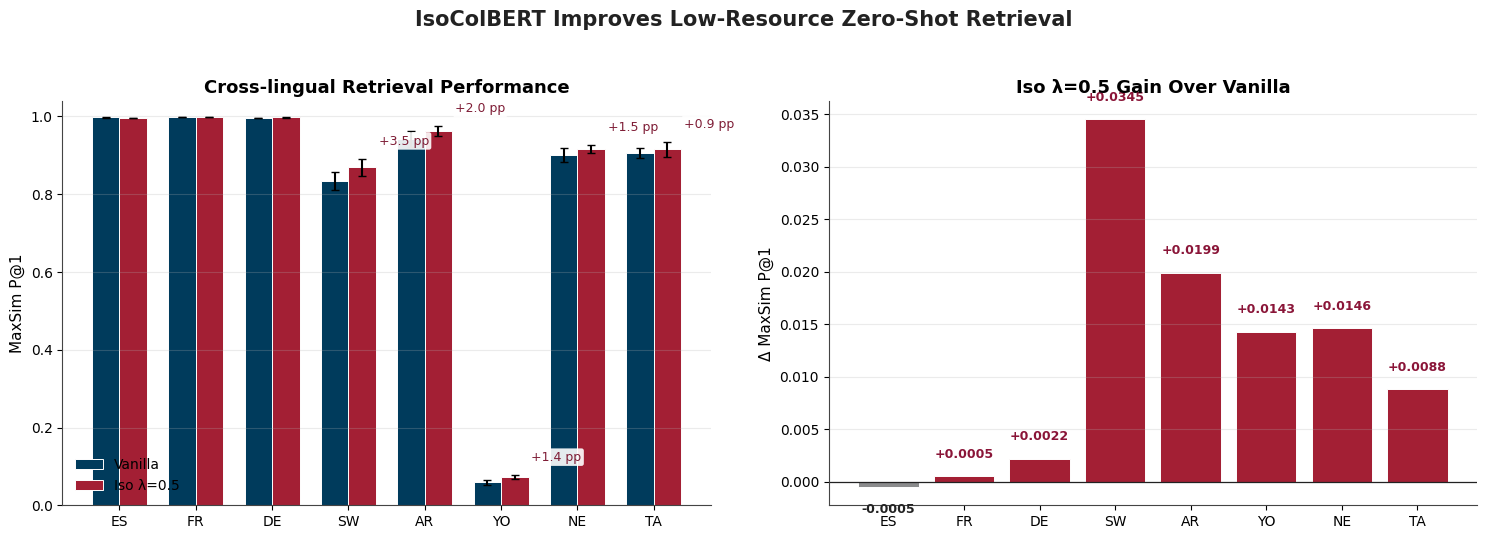

Saved: /content/drive/MyDrive/iso_colbert_lam0p5/isocolbert_all_maxsim_p1_mit_theme.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import os

# MIT-ish colors
MIT_RED = '#A31F34'
MIT_DARK_RED = '#8A1538'
MIT_BLUE = '#003B5C'
MIT_GRAY = '#8A8B8C'
MIT_LIGHT_GRAY = '#E5E5E5'
TEXT = '#222222'

names_p1 = ['ES', 'FR', 'DE', 'SW', 'AR', 'YO', 'NE', 'TA']
keys_p1  = ['p1_es', 'p1_fr', 'p1_de', 'p1_sw', 'p1_ar', 'p1_yo', 'p1_ne', 'p1_ta']

van_mu = [agg_all('vanilla', k)[0] for k in keys_p1]
van_sd = [agg_all('vanilla', k)[1] for k in keys_p1]
iso_mu = [agg_all('iso_lam0p5', k)[0] for k in keys_p1]
iso_sd = [agg_all('iso_lam0p5', k)[1] for k in keys_p1]

delta = [i - v for i, v in zip(iso_mu, van_mu)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# =========================
# Left: MaxSim P@1
# =========================
ax = axes[0]
x = np.arange(len(names_p1))
w = 0.36

ax.bar(
    x - w/2, van_mu, w,
    yerr=van_sd,
    label='Vanilla',
    color=MIT_BLUE,
    capsize=3,
    edgecolor='white',
    linewidth=0.7
)

ax.bar(
    x + w/2, iso_mu, w,
    yerr=iso_sd,
    label='Iso λ=0.5',
    color=MIT_RED,
    capsize=3,
    edgecolor='white',
    linewidth=0.7
)

ax.set_xticks(x)
ax.set_xticklabels(names_p1, fontsize=10)
ax.set_ylabel('MaxSim P@1', fontsize=11)
ax.set_title('Cross-lingual Retrieval Performance', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.04)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

# Annotate gains where visible/useful
for i, d in enumerate(delta):
    if d > 0.004:
        y_top = iso_mu[i] + iso_sd[i]

        ax.annotate(
            f"+{d*100:.1f} pp",
            xy=(i + w/2, y_top),              # top of iso bar / error bar
            xytext=(12, 8),                  # move label right and a bit up
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=9,
            color=GAIN_COLOR,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.9
            )
        )
# =========================
# Right: Iso gain over vanilla
# =========================
ax = axes[1]

bar_colors = [MIT_RED if d >= 0 else MIT_GRAY for d in delta]

ax.bar(
    x, delta,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.7
)

ax.axhline(0, color=TEXT, linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(names_p1, fontsize=10)
ax.set_ylabel('Δ MaxSim P@1', fontsize=11)
ax.set_title('Iso λ=0.5 Gain Over Vanilla', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

for i, d in enumerate(delta):
    ax.text(
        i,
        d + (0.0015 if d >= 0 else -0.0015),
        f'{d:+.4f}',
        ha='center',
        va='bottom' if d >= 0 else 'top',
        fontsize=9,
        fontweight='bold',
        color=MIT_DARK_RED if d >= 0 else TEXT
    )

fig.suptitle(
    'IsoColBERT Improves Low-Resource Zero-Shot Retrieval',
    fontsize=15,
    fontweight='bold',
    color=TEXT,
    y=1.03
)

plt.tight_layout()

fig_path = os.path.join(SAVE_DIR, 'isocolbert_all_maxsim_p1_mit_theme.png')
plt.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved:', fig_path)

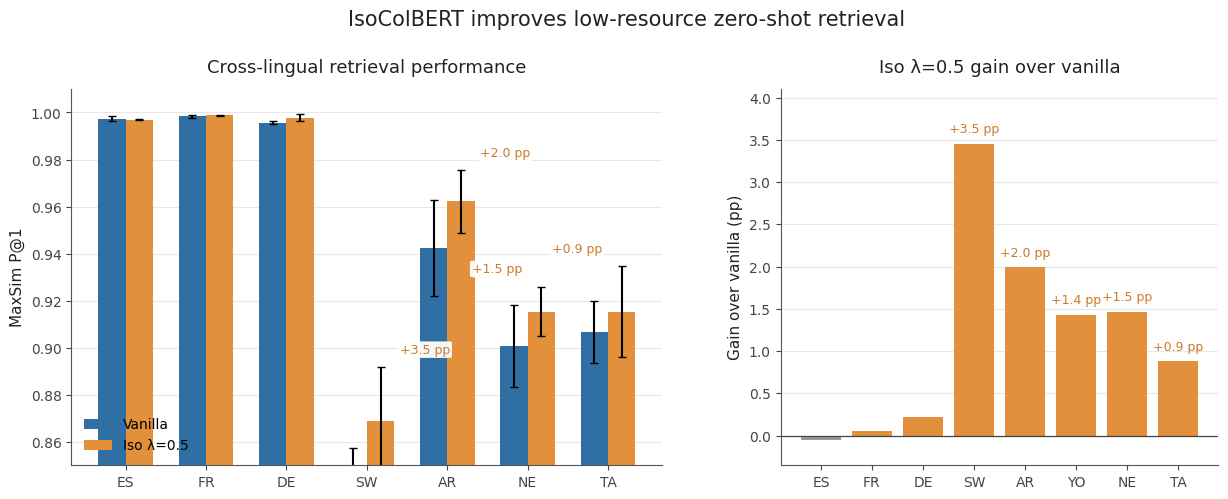

Saved: /content/drive/MyDrive/iso_colbert_lam0p5/isocolbert_clean_maxsim_results_final.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Blue + orange palette inspired by your icon
VANILLA_COLOR = "#2F6FA3"
ISO_COLOR = "#E2903B"
GAIN_COLOR = "#CC7A29"
NEG_COLOR = "#9A9A9A"
GRID_COLOR = "#E1E1E1"
TEXT_COLOR = "#222222"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "normal",
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#555555",
    "axes.linewidth": 0.8,
})

# =========================
# Left panel data
# YO excluded because left panel starts at 0.85
# =========================
names_p1 = ["ES", "FR", "DE", "SW", "AR", "NE", "TA"]
keys_p1  = ["p1_es", "p1_fr", "p1_de", "p1_sw", "p1_ar", "p1_ne", "p1_ta"]

van_mu = np.array([agg_all("vanilla", k)[0] for k in keys_p1])
van_sd = np.array([agg_all("vanilla", k)[1] for k in keys_p1])
iso_mu = np.array([agg_all("iso_lam0p5", k)[0] for k in keys_p1])
iso_sd = np.array([agg_all("iso_lam0p5", k)[1] for k in keys_p1])
delta = iso_mu - van_mu

# =========================
# Right panel data
# Includes YO
# =========================
names_gain = ["ES", "FR", "DE", "SW", "AR", "YO", "NE", "TA"]
keys_gain  = ["p1_es", "p1_fr", "p1_de", "p1_sw", "p1_ar", "p1_yo", "p1_ne", "p1_ta"]

gain_van = np.array([agg_all("vanilla", k)[0] for k in keys_gain])
gain_iso = np.array([agg_all("iso_lam0p5", k)[0] for k in keys_gain])
gain_delta = gain_iso - gain_van
gain_pp = gain_delta * 100

# =========================
# Figure
# =========================
fig, axes = plt.subplots(
    1, 2,
    figsize=(14.8, 5.3),
    gridspec_kw={"width_ratios": [1.35, 1]}
)

# more room so nothing overlaps
fig.subplots_adjust(top=0.82, wspace=0.23)

# =========================================================
# Left panel
# =========================================================
ax = axes[0]
x = np.arange(len(names_p1))
w = 0.34

ax.bar(
    x - w / 2, van_mu, w,
    yerr=van_sd,
    label="Vanilla",
    color=VANILLA_COLOR,
    capsize=3,
    linewidth=0
)

ax.bar(
    x + w / 2, iso_mu, w,
    yerr=iso_sd,
    label="Iso λ=0.5",
    color=ISO_COLOR,
    capsize=3,
    linewidth=0
)

ax.set_xticks(x)
ax.set_xticklabels(names_p1)
ax.set_ylabel("MaxSim P@1", color=TEXT_COLOR)
ax.set_title("Cross-lingual retrieval performance", color=TEXT_COLOR, pad=12)
ax.set_ylim(0.85, 1.01)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors="#444444")
ax.legend(loc="lower left", frameon=False)

# label placement tuned so text does not sit on error bars
label_offsets = {
    "SW": (14, 8, "left"),
    "AR": (14, 8, "left"),
    "NE": (-14, 8, "right"),
    "TA": (-14, 8, "right"),
}

for i, (name, d) in enumerate(zip(names_p1, delta)):
    if d > 0.004:
        y_top = iso_mu[i] + iso_sd[i]
        xoff, yoff, ha = label_offsets.get(name, (12, 8, "left"))

        ax.annotate(
            f"+{d*100:.1f} pp",
            xy=(i + w / 2, y_top),
            xytext=(xoff, yoff),
            textcoords="offset points",
            ha=ha,
            va="bottom",
            fontsize=9,
            color=GAIN_COLOR,
            bbox=dict(
                boxstyle="round,pad=0.14",
                facecolor="white",
                edgecolor="none",
                alpha=0.95
            )
        )

# =========================================================
# Right panel
# =========================================================
ax = axes[1]
x2 = np.arange(len(names_gain))
colors = [ISO_COLOR if d >= 0 else NEG_COLOR for d in gain_pp]

ax.bar(
    x2, gain_pp,
    color=colors,
    linewidth=0
)

ax.axhline(0, color="#444444", linewidth=0.9)
ax.set_xticks(x2)
ax.set_xticklabels(names_gain)
ax.set_ylabel("Gain over vanilla (pp)", color=TEXT_COLOR)
ax.set_title("Iso λ=0.5 gain over vanilla", color=TEXT_COLOR, pad=12)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors="#444444")

# enough room so labels do not hit the title or x-axis
ax.set_ylim(min(-0.35, gain_pp.min() - 0.25), gain_pp.max() + 0.65)

# label only meaningful values
for i, d in enumerate(gain_pp):
    if abs(d) < 0.5:
        continue

    ax.annotate(
        f"{d:+.1f} pp",
        xy=(i, d),
        xytext=(0, 6 if d >= 0 else -6),
        textcoords="offset points",
        ha="center",
        va="bottom" if d >= 0 else "top",
        fontsize=9,
        color=GAIN_COLOR if d >= 0 else TEXT_COLOR
    )

# Overall title
fig.suptitle(
    "IsoColBERT improves low-resource zero-shot retrieval",
    fontsize=15,
    fontweight="normal",
    color=TEXT_COLOR,
    y=0.97
)

fig_path = os.path.join(SAVE_DIR, "isocolbert_clean_maxsim_results_final.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [33]:
!pip install -q matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

!wget -q https://github.com/google/fonts/raw/main/ofl/titilliumweb/TitilliumWeb-Regular.ttf -O /tmp/TitilliumWeb-Regular.ttf
font_manager.fontManager.addfont('/tmp/TitilliumWeb-Regular.ttf')
mpl.rcParams['font.family'] = 'Titillium Web'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Titillium Web'
mpl.rcParams['mathtext.it'] = 'Titillium Web:italic'
mpl.rcParams['mathtext.bf'] = 'Titillium Web:bold'

equations = {
    'maxsim':    r'$S(q, d) \;=\; \sum_{i}\, \max_{j}\, \mathbf{q}_i \cdot \mathbf{d}_j$',
    'objective': r'$\mathcal{L} \;=\; \mathcal{L}_{\mathrm{InfoNCE}} \;+\; \lambda \cdot \mathcal{L}_{\mathrm{iso}}$',
    'meansq':    r'$\mathrm{MeanSq}_{\mathrm{off}}(V) \;=\; \frac{1}{|V|(|V|-1)} \sum_{i \neq j}\, (\mathbf{v}_i \cdot \mathbf{v}_j)^2$',
    'uniform':   r'$\mathcal{L}_{\mathrm{iso}}^{\mathrm{uniform}} \;=\; \frac{1}{2}\left(\mathrm{MeanSq}_{\mathrm{off}}(Q) + \mathrm{MeanSq}_{\mathrm{off}}(D)\right)$',
    'active':    r'$\mathcal{L}_{\mathrm{iso}}^{\mathrm{active}} \;=\; \frac{1}{2}\left(\mathrm{MeanSq}_{\mathrm{off}}(Q_{\mathrm{act}}) + \mathrm{MeanSq}_{\mathrm{off}}(D_{\mathrm{act}})\right)$',
    'crossattn': r'$\mathcal{L}_{\mathrm{iso}}^{\mathrm{cross\!-\!attn}} \;=\; \mathrm{MeanSq}_{\mathrm{off}}(A)$',
}

for name, eq in equations.items():
    fig, ax = plt.subplots(figsize=(10, 1.3))
    ax.text(0.5, 0.5, eq, fontsize=22, ha='center', va='center')
    ax.axis('off')
    plt.savefig(f'/content/eq_{name}.png', dpi=300, bbox_inches='tight',
                transparent=True, pad_inches=0.15)
    plt.close()

print('Saved: eq_maxsim, eq_objective, eq_meansq, eq_uniform, eq_active, eq_crossattn (PNG)')

Saved: eq_maxsim, eq_objective, eq_meansq, eq_uniform, eq_active, eq_crossattn (PNG)


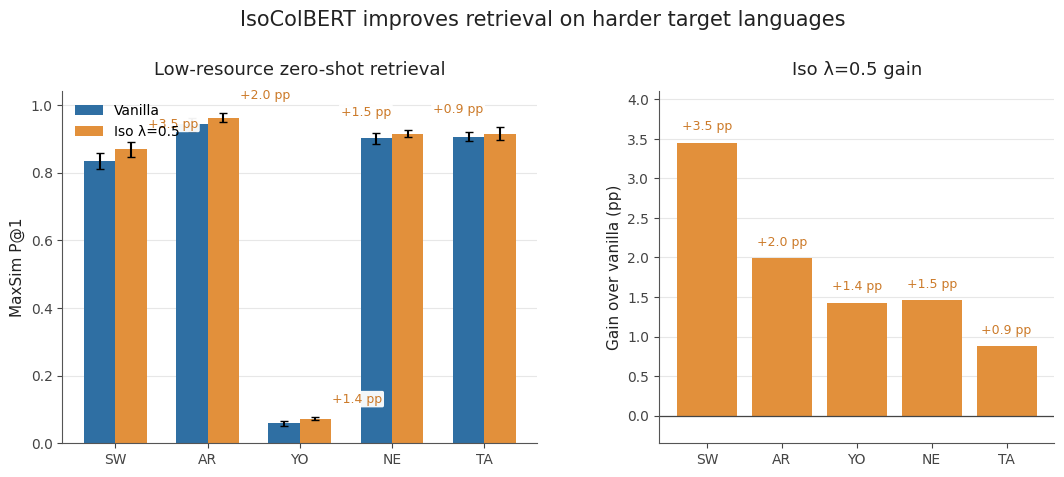

Saved: /content/drive/MyDrive/iso_colbert_lam0p5/isocolbert_low_resource_only.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Blue + orange palette inspired by your icon
VANILLA_COLOR = "#2F6FA3"
ISO_COLOR = "#E2903B"
GAIN_COLOR = "#CC7A29"
NEG_COLOR = "#9A9A9A"
GRID_COLOR = "#E1E1E1"
TEXT_COLOR = "#222222"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "normal",
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#555555",
    "axes.linewidth": 0.8,
})

# =========================================================
# Show only harder / low-resource evals
# =========================================================
names_p1 = ["SW", "AR", "YO", "NE", "TA"]
keys_p1  = ["p1_sw", "p1_ar", "p1_yo", "p1_ne", "p1_ta"]

van_mu = np.array([agg_all("vanilla", k)[0] for k in keys_p1])
van_sd = np.array([agg_all("vanilla", k)[1] for k in keys_p1])
iso_mu = np.array([agg_all("iso_lam0p5", k)[0] for k in keys_p1])
iso_sd = np.array([agg_all("iso_lam0p5", k)[1] for k in keys_p1])

delta = iso_mu - van_mu
delta_pp = delta * 100

# =========================================================
# Figure
# =========================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(12.8, 5.1),
    gridspec_kw={"width_ratios": [1.2, 1]}
)

fig.subplots_adjust(top=0.80, wspace=0.28)

# =========================================================
# Left panel: P@1
# =========================================================
ax = axes[0]
x = np.arange(len(names_p1))
w = 0.34

ax.bar(
    x - w / 2,
    van_mu,
    w,
    yerr=van_sd,
    label="Vanilla",
    color=VANILLA_COLOR,
    capsize=3,
    linewidth=0,
)

ax.bar(
    x + w / 2,
    iso_mu,
    w,
    yerr=iso_sd,
    label="Iso λ=0.5",
    color=ISO_COLOR,
    capsize=3,
    linewidth=0,
)

ax.set_xticks(x)
ax.set_xticklabels(names_p1)
ax.set_ylabel("MaxSim P@1", color=TEXT_COLOR)
ax.set_title("Low-resource zero-shot retrieval", color=TEXT_COLOR, pad=12)

# Need full scale because YO is genuinely hard / low absolute P@1
ax.set_ylim(0.0, 1.04)

ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors="#444444")
ax.legend(loc="upper left", frameon=False)

# Gain labels on left panel, placed away from error bars
label_offsets = {
    "SW": (12, 8, "left"),
    "AR": (12, 8, "left"),
    "YO": (12, 8, "left"),
    "NE": (-12, 8, "right"),
    "TA": (-12, 8, "right"),
}

for i, (name, d) in enumerate(zip(names_p1, delta_pp)):
    if d > 0.5:
        y_top = iso_mu[i] + iso_sd[i]
        xoff, yoff, ha = label_offsets.get(name, (12, 8, "left"))

        ax.annotate(
            f"+{d:.1f} pp",
            xy=(i + w / 2, y_top),
            xytext=(xoff, yoff),
            textcoords="offset points",
            ha=ha,
            va="bottom",
            fontsize=9,
            color=GAIN_COLOR,
            bbox=dict(
                boxstyle="round,pad=0.14",
                facecolor="white",
                edgecolor="none",
                alpha=0.95,
            ),
        )

# =========================================================
# Right panel: gain over vanilla
# =========================================================
ax = axes[1]
x2 = np.arange(len(names_p1))

colors = [ISO_COLOR if d >= 0 else NEG_COLOR for d in delta_pp]

ax.bar(
    x2,
    delta_pp,
    color=colors,
    linewidth=0,
)

ax.axhline(0, color="#444444", linewidth=0.9)
ax.set_xticks(x2)
ax.set_xticklabels(names_p1)
ax.set_ylabel("Gain over vanilla (pp)", color=TEXT_COLOR)
ax.set_title("Iso λ=0.5 gain", color=TEXT_COLOR, pad=12)

ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors="#444444")

ax.set_ylim(
    min(-0.35, delta_pp.min() - 0.25),
    delta_pp.max() + 0.65
)

for i, d in enumerate(delta_pp):
    ax.annotate(
        f"+{d:.1f} pp" if d >= 0 else f"{d:.1f} pp",
        xy=(i, d),
        xytext=(0, 7 if d >= 0 else -7),
        textcoords="offset points",
        ha="center",
        va="bottom" if d >= 0 else "top",
        fontsize=9,
        color=GAIN_COLOR if d >= 0 else TEXT_COLOR,
    )

fig.suptitle(
    "IsoColBERT improves retrieval on harder target languages",
    fontsize=15,
    fontweight="normal",
    color=TEXT_COLOR,
    y=0.96,
)

fig_path = os.path.join(SAVE_DIR, "isocolbert_low_resource_only.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [36]:
!pip install -q matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

!wget -q https://github.com/google/fonts/raw/main/ofl/titilliumweb/TitilliumWeb-Regular.ttf -O /tmp/TitilliumWeb-Regular.ttf
font_manager.fontManager.addfont('/tmp/TitilliumWeb-Regular.ttf')
mpl.rcParams['font.family'] = 'Titillium Web'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Titillium Web'
mpl.rcParams['mathtext.it'] = 'Titillium Web:italic'
mpl.rcParams['mathtext.bf'] = 'Titillium Web:bold'

# Three equations for Method. (name, latex, boxed?)
equations = [
    ('maxsim',
     r'$S(q, d) \;=\; \sum_{i}\, \max_{j}\, \mathbf{q}_i \cdot \mathbf{d}_j$',
     False),
    ('objective',
     r'$\mathcal{L} \;=\; \mathcal{L}_{\mathrm{InfoNCE}} \;+\; \lambda \cdot \mathcal{L}_{\mathrm{iso}}$',
     True),
    ('iso',
     r'$\mathcal{L}_{\mathrm{iso}} \;=\; \frac{1}{2}\left( \mathbb{E}_{i \neq j}\!\left[(\mathbf{q}_i \cdot \mathbf{q}_j)^2\right] + \mathbb{E}_{i \neq j}\!\left[(\mathbf{d}_i \cdot \mathbf{d}_j)^2\right] \right)$',
     False),
]

for name, eq, boxed in equations:
    fig, ax = plt.subplots(figsize=(10, 1.3))
    if boxed:
        ax.text(0.5, 0.5, eq, fontsize=22, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.5',
                          edgecolor='black', facecolor='none', linewidth=1.5))
    else:
        ax.text(0.5, 0.5, eq, fontsize=22, ha='center', va='center')
    ax.axis('off')
    plt.savefig(f'/content/eq_{name}.png', dpi=300, bbox_inches='tight',
                transparent=True, pad_inches=0.15)
    plt.close()

print('Saved 3 PNGs to /content/:')
print('  eq_maxsim.png    — MaxSim score')
print('  eq_objective.png — Total objective (BOXED)')
print('  eq_iso.png       — Isotropy loss (expanded, no MeanSq-off operator)')

Saved 3 PNGs to /content/:
  eq_maxsim.png    — MaxSim score
  eq_objective.png — Total objective (BOXED)
  eq_iso.png       — Isotropy loss (expanded, no MeanSq-off operator)
